In [3]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

##### Get the cosmological parameters

In [32]:
wind_en  = []
wind_vel = []
bh_eff   = []
gas_ts   = []
quas_thr = []
imf_sl   = []

with open("/scratch/fgmaion/CAMELS/1P/CosmoAstroSeed_IllustrisTNG_L25n256_1P.txt", 'r') as f:
    for line in f.readlines():
        if '1P_p3' in line.split()[0] or '1P_p5' in line.split()[0] or '1P_p26' in line.split()[0] or '1P_p10' in line.split()[0] or '1P_p27' in line.split()[0] or '1P_p12' in line.split()[0]:
            wind_en.append(float(line.split()[3]))
            wind_vel.append(float(line.split()[5]))
            bh_eff.append(float(line.split()[26]))
            gas_ts.append(float(line.split()[10]))
            quas_thr.append(float(line.split()[27]))
            imf_sl.append(float(line.split()[12]))

wind_en  = np.asarray(wind_en)
wind_vel = np.asarray(wind_vel)
bh_eff   = np.asarray(bh_eff)
gas_ts   = np.asarray(gas_ts)
quas_thr = np.asarray(quas_thr)
imf_sl   = np.asarray(imf_sl)

In [39]:
pars = [3, 5, 26, 10, 27, 12]
id_names = ['n2', 'n1', '0', '1', '2']

##### Get the baseline data

In [36]:
base_data = utils.camels_stellar_mf('1P', baseline=True, nbins=15)

/lscratch/fgmaion/MTNG-resims/src/utils.py:593: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}


In [52]:
def pars(i, mstar):

    arr = np.vstack( (mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * bh_eff[i],\
                        np.ones(len(mstar)) * gas_ts[i],\
                        np.ones(len(mstar)) * quas_thr[i],\
                        np.ones(len(mstar)) * imf_sl[i] )).T

    return arr

### Get the data

In [48]:
smf = {}
for i in range(30):
    smf[i] = utils.camels_stellar_mf('1P', id_name=id_names[i//6], par=i%5+1, nbins=15)


/lscratch/fgmaion/MTNG-resims/src/utils.py:593: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}


In [84]:
train_sel = random.sample(range(30), 25)
test_sel  = np.delete(range(30), train_sel)

In [85]:
#del smf_global, arr_global
mstar = np.log10(smf[train_sel[0]]['mstar'][:-3])
arr_global = pars(0, mstar)
smf_global = np.log10(smf[train_sel[0]]['smf'][:-3])

for i in range(1,25):
    mstar = np.log10(smf[train_sel[i]]['mstar'][:-3])

    arr = pars(train_sel[i], mstar)

    arr_global = np.vstack((arr_global, arr))

    smf_global = np.hstack((smf_global, np.log10(smf[train_sel[i]]['smf'][:-3])))

isnan = np.where(np.isnan(arr_global))[0]

arr_global = np.delete(arr_global, isnan, axis=0)
smf_global = np.delete(smf_global, isnan)

/tmp/ipykernel_280774/2591272925.py:13: RuntimeWarning: divide by zero encountered in log10
  smf_global = np.hstack((smf_global, np.log10(smf[train_sel[i]]['smf'][:-3])))


In [86]:
#Training data is 100 points in [0,1] inclusive regularly spaced
#train_x = torch.vstack([torch.linspace(0, 1, 100),torch.linspace(0, 1, 100)]).T
#True function is sin(2*pi*x) with Gaussian noise
#train_y = torch.sin(train_x[:,0] * (2 * math.pi)) + torch.randn(train_x[:,0].size()) * math.sqrt(0.04)

In [87]:
train_x = torch.asarray(arr_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

### Build the GP Model

In [88]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=7))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

In [89]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [101]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 400


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -torch.sum(mll(output, train_y))
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/400 - Loss: -0.059   noise: 0.040
Iter 2/400 - Loss: -0.056   noise: 0.037
Iter 3/400 - Loss: -0.059   noise: 0.039
Iter 4/400 - Loss: -0.059   noise: 0.042
Iter 5/400 - Loss: -0.057   noise: 0.043
Iter 6/400 - Loss: -0.058   noise: 0.043
Iter 7/400 - Loss: -0.059   noise: 0.042
Iter 8/400 - Loss: -0.059   noise: 0.041
Iter 9/400 - Loss: -0.059   noise: 0.039
Iter 10/400 - Loss: -0.058   noise: 0.038
Iter 11/400 - Loss: -0.058   noise: 0.038
Iter 12/400 - Loss: -0.059   noise: 0.039
Iter 13/400 - Loss: -0.059   noise: 0.040
Iter 14/400 - Loss: -0.059   noise: 0.040
Iter 15/400 - Loss: -0.059   noise: 0.041
Iter 16/400 - Loss: -0.059   noise: 0.042
Iter 17/400 - Loss: -0.059   noise: 0.042
Iter 18/400 - Loss: -0.059   noise: 0.042
Iter 19/400 - Loss: -0.059   noise: 0.041
Iter 20/400 - Loss: -0.059   noise: 0.040
Iter 21/400 - Loss: -0.059   noise: 0.040
Iter 22/400 - Loss: -0.059   noise: 0.039
Iter 23/400 - Loss: -0.059   noise: 0.039
Iter 24/400 - Loss: -0.059   noise: 0.039
I

In [102]:
mstar_test = np.linspace(8,11,15)
test_x1 = torch.asarray(pars(train_sel[5], np.log10(smf[train_sel[5]]['mstar'][:-5])), dtype=torch.float)
test_x2 = torch.asarray(pars(test_sel[4], np.log10(smf[test_sel[4]]['mstar'][:-5])), dtype=torch.float)

In [103]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred1 = likelihood(model(test_x1))
    observed_pred2 = likelihood(model(test_x2))

Text(0, 0.5, 'SMF')

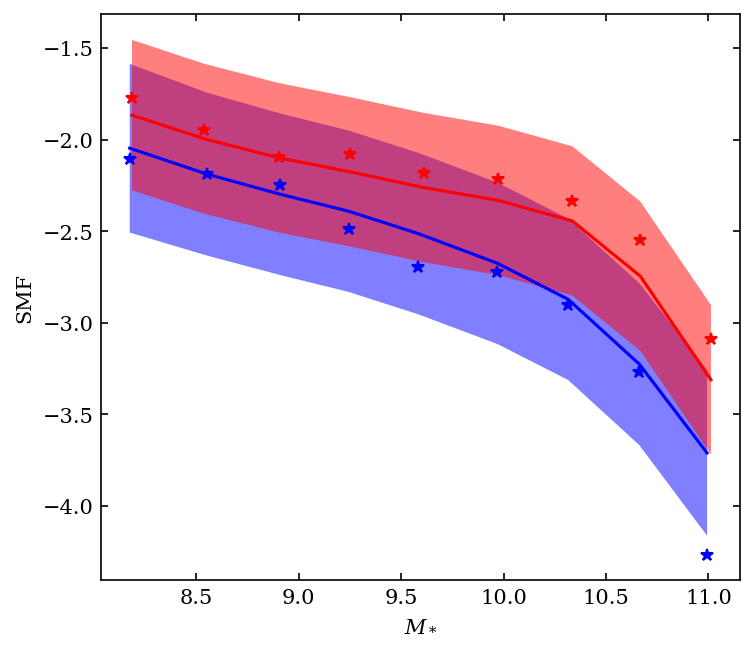

In [104]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=150)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax.plot(np.log10(smf[train_sel[5]]['mstar'][:-5]), np.log10(smf[train_sel[5]]['smf'][:-5]), 'b*')
    ax.plot(np.log10(smf[test_sel[4]]['mstar'][:-5]), np.log10(smf[test_sel[4]]['smf'][:-5]), 'r*')

    # Plot predictive means as blue line
    ax.plot(test_x1[:,0], observed_pred1.mean.numpy(), 'b')
    ax.plot(test_x2[:,0], observed_pred2.mean.numpy(), 'r')

    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x1.numpy()[:,0], lower1.numpy(), upper1.numpy(), alpha=0.5, color='b', edgecolor=None)
    ax.fill_between(test_x2.numpy()[:,0], lower2.numpy(), upper2.numpy(), alpha=0.5, color='r', edgecolor=None)

ax.set_xlabel('$M_*$')
ax.set_ylabel('SMF')


Text(0.5, 1.0, 'Validation Data [51-100]')

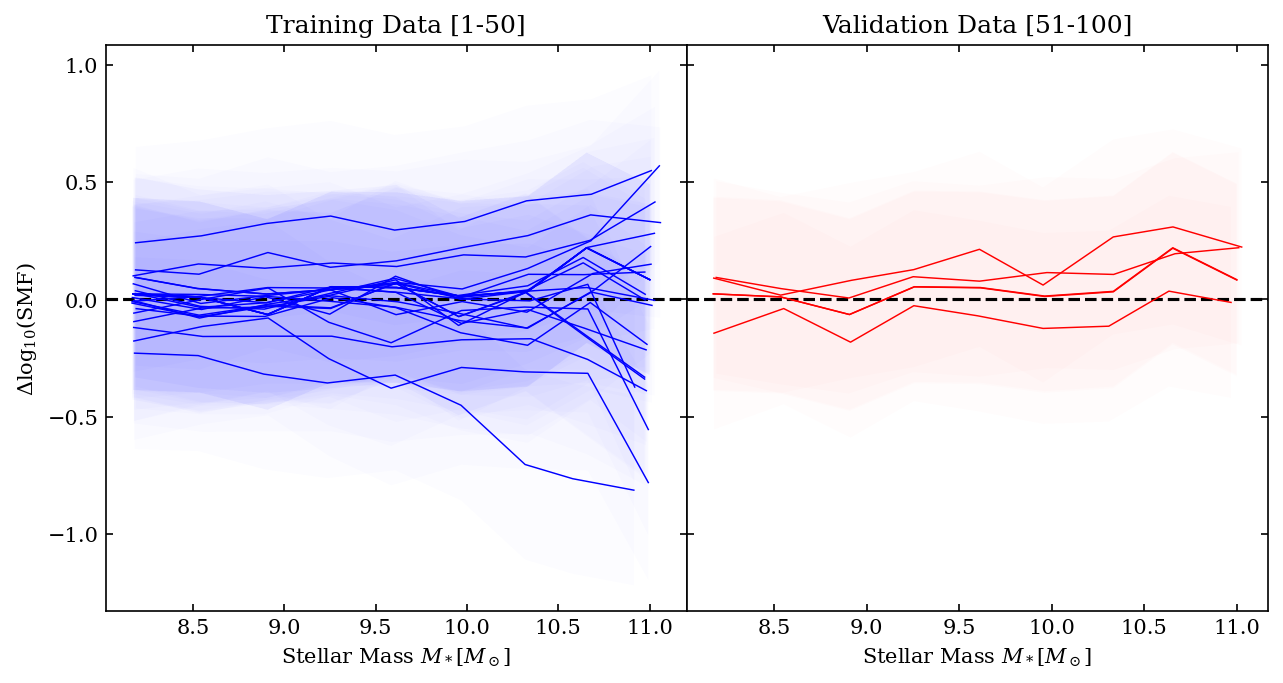

In [107]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax[0].axhline(0, color='k', ls='--')
    ax[1].axhline(0, color='k', ls='--')

    for i in range(25):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
            lower1, upper1 = observed_pred1.confidence_region()
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  np.log10(smf[train_sel[i]]['smf'][:-5]) - observed_pred1.mean.numpy(), color='b', lw=0.7)
        ax[0].fill_between(np.log10(smf[train_sel[i]]['mstar'][:-5]), np.log10(smf[train_sel[i]]['smf'][:-5]) - lower1.numpy(), np.log10(smf[train_sel[i]]['smf'][:-5]) - upper1.numpy(), alpha=0.01, color='b', edgecolor=None)

    for i in range(5):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
            lower2, upper2 = observed_pred2.confidence_region()
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - lower2.numpy(), np.log10(smf[test_sel[i]]['smf'][:-5]) - upper2.numpy(), alpha=0.01, color='r', edgecolor=None)

ax[0].set_ylabel('$\Delta \log_{10}(\\mathrm{SMF})$')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-50]')
ax[1].set_title('Validation Data [51-100]')

Text(0.5, 1.0, 'Validation Data [51-100]')

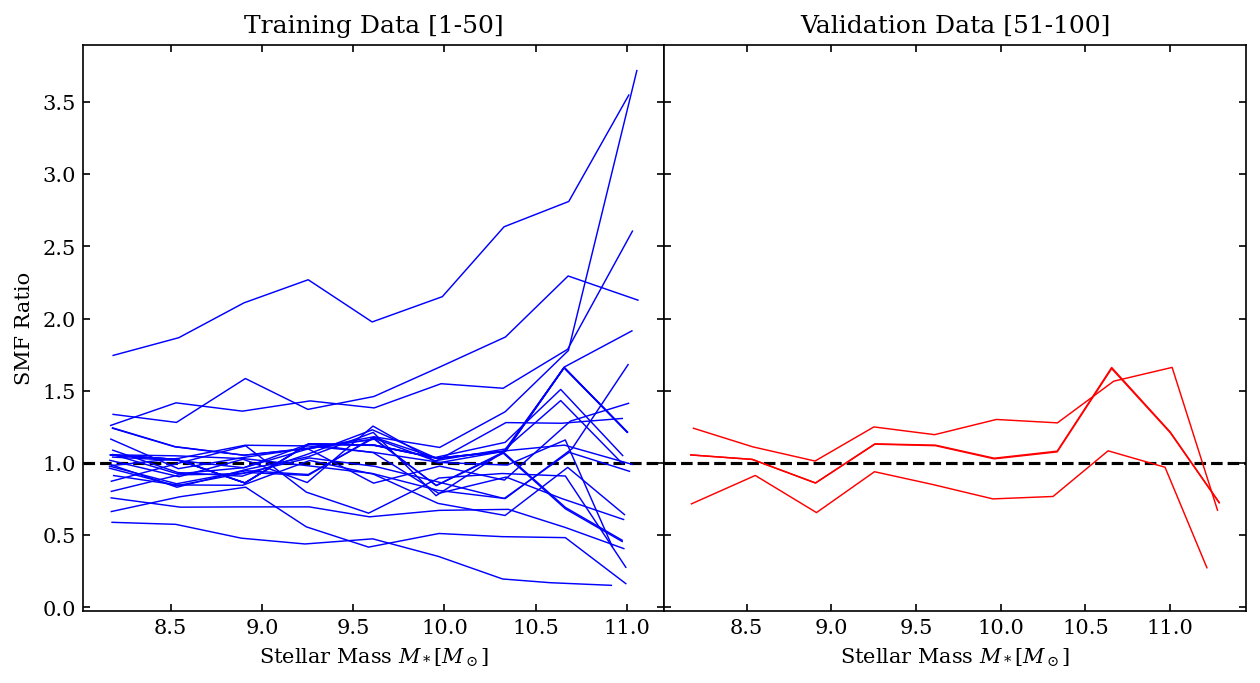

In [106]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax[0].axhline(1, color='k', ls='--')
    ax[1].axhline(1, color='k', ls='--')

    for i in range(25):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
            lower1, upper1 = observed_pred1.confidence_region()
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  smf[train_sel[i]]['smf'][:-5] / 10**observed_pred1.mean.numpy(), color='b', lw=0.7)

    for i in range(5):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-4])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
            lower2, upper2 = observed_pred2.confidence_region()
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-4]), smf[test_sel[i]]['smf'][:-4] / 10**observed_pred2.mean.numpy(), color='r', lw=0.7)

ax[0].set_ylabel('SMF Ratio')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-50]')
ax[1].set_title('Validation Data [51-100]')